# 📊 Netflix Data Analysis

Este projeto realiza uma análise exploratória de dados (EDA) do catálogo da plataforma de streaming **Netflix**.

O objetivo é compreender padrões do catálogo e responder perguntas relevantes sobre o conteúdo disponível.

Principais perguntas analisadas:

- Quantos **filmes vs séries** existem?
- Quais **países produzem mais conteúdo**?
- Quais **gêneros são mais comuns**?
- Como evoluiu a **adição de conteúdos ao longo do tempo**?
- Qual a **distribuição de ratings**?

Além disso, o projeto demonstra etapas fundamentais de um fluxo de análise de dados:

1. Limpeza de dados
2. Transformação de variáveis
3. Análise exploratória
4. Visualização de dados

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 📂 Carregamento do Dataset

In [10]:
df = pd.read_csv(r"C:\Users\vinir\OneDrive\Área de Trabalho\devroot\My-portifolio\portifolio\Limpeza de dados\data\NetFlix.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


## 🔎 Entendimento dos Dados

Nesta etapa analisamos a estrutura do dataset e verificamos:

- tipos de dados
- valores ausentes
- distribuição inicial das variáveis

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   int64 
 10  genres        7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(2), object(10)
memory usage: 730.2+ KB


In [12]:
df.describe()

,release_year,duration
count,7787.000000,7787.000000
mean,2013.932580,69.122769
std,8.757395,50.950743
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2018.000000,106.000000
max,2021.000000,312.000000


## ⚠️ Valores Ausentes

In [13]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

## 🧹 Limpeza de Dados

Algumas colunas possuem valores ausentes.

Estratégias adotadas:

- director, cast e country → preenchidos com "Unknown"
- date_added → linhas removidas
- rating → preenchido com a moda

In [14]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

df = df.dropna(subset=["date_added"])

df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

## ⚙️ Feature Engineering

Para facilitar a análise foram criadas novas variáveis:

- país principal de produção
- separação de gêneros
- ano de adição do conteúdo

In [15]:
# pegar primeiro país
df["country_main"] = df["country"].str.split(",").str[0]

# transformar gêneros em colunas
genres_dummies = df["genres"].str.get_dummies(sep=", ")

df = pd.concat([df, genres_dummies], axis=1)

df = df.drop(columns=["genres"])

## 🎬 Filmes vs Séries

### Pergunta
Quantos filmes e séries existem no catálogo?

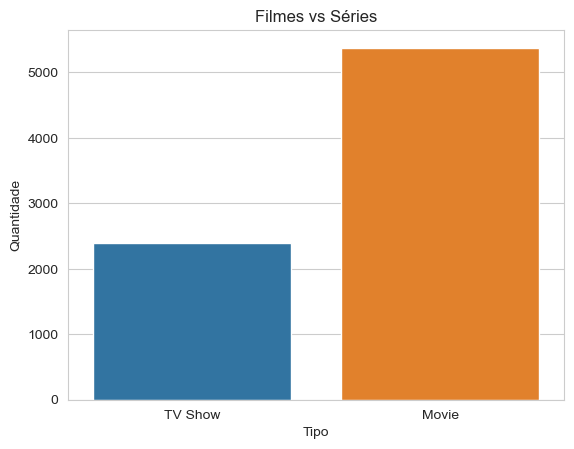

In [31]:
sns.countplot(data=df, x="type")

plt.title("Filmes vs Séries")
plt.xlabel("Tipo")
plt.ylabel("Quantidade")
plt.savefig("C:\\Users\\vinir\\OneDrive\\Área de Trabalho\\devroot\\My-portifolio\\portifolio\\Limpeza de dados\\imgs\\Filmes_vs_Series.png") 
plt.show()

### Insight

Filmes representam a maior parte do catálogo disponível na plataforma.

## 🌎 Países com mais produções

### Pergunta

Qual pais gera mais conteúdo?

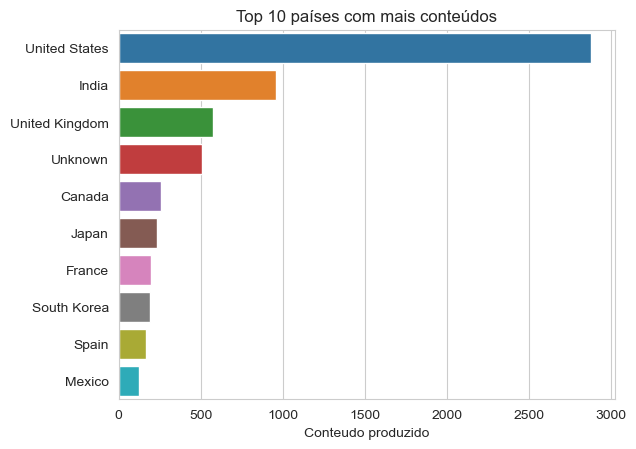

In [30]:
top_countries = df["country_main"].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top 10 países com mais conteúdos")
plt.xlabel("Conteudo produzido")
plt.savefig("C:\\Users\\vinir\\OneDrive\\Área de Trabalho\\devroot\\My-portifolio\\portifolio\\Limpeza de dados\\imgs\\Top_10_Paises.png") 
plt.show()

### Insight

Os Estados Unidos lideram a produção de conteúdo, seguidos por Índia e Reino Unido.

## 🎭 Gêneros mais comuns

### Pergunta:
Quais são os gêneros mais comuns no catálogo?

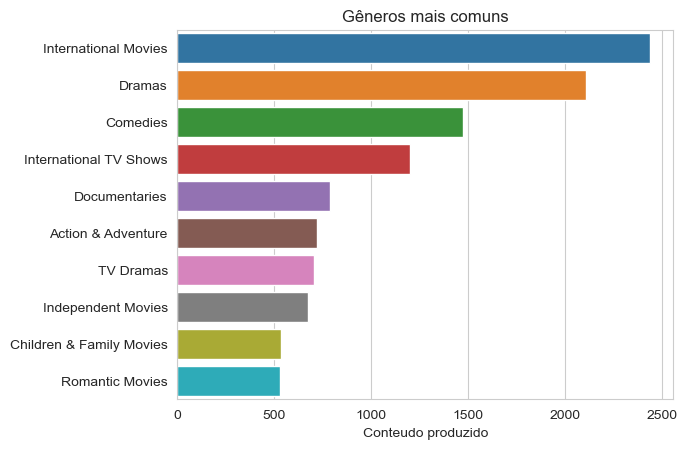

In [29]:
top_genres = genres_dummies.sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title("Gêneros mais comuns")
plt.xlabel("Conteudo produzido")
plt.savefig("C:\\Users\\vinir\\OneDrive\\Área de Trabalho\\devroot\\My-portifolio\\portifolio\\Limpeza de dados\\imgs\\Generos_Mais_Comuns.png") 
plt.show()

### Insight:
Drama e Comédia aparecem entre os gêneros mais frequentes, indicando forte preferência por conteúdos narrativos e de entretenimento geral.

## 📈 Conteúdos adicionados por ano

### Pergunta:
Como evoluiu a adição de conteúdos ao longo do tempo?

<Axes: ylabel='Quantidade'>

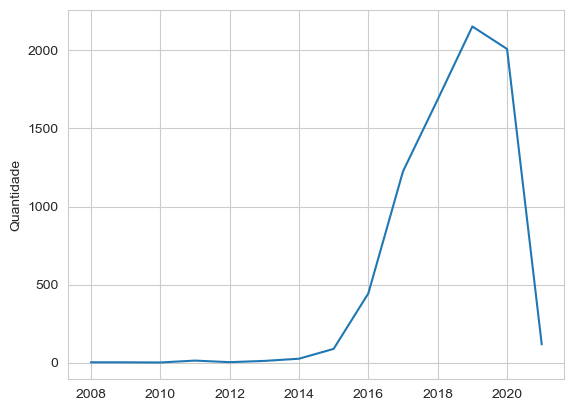

In [28]:
df["date_added"] = pd.to_datetime(df["date_added"])
df["year_added"] = df["date_added"].dt.year

content_per_year = df["year_added"].value_counts().sort_index()
plt.ylabel("Quantidade")
plt.savefig("C:\\Users\\vinir\\OneDrive\\Área de Trabalho\\devroot\\My-portifolio\\portifolio\\Limpeza de dados\\imgs\\Conteudo_Por_Ano.png") 
content_per_year.plot()

### Insight:
Observa-se crescimento acelerado após 2016, indicando expansão global da plataforma e aumento na produção de conteúdos originais.

## ⭐ Distribuição de ratings
### Pergunta:
Qual a classificação indicativa predominante?

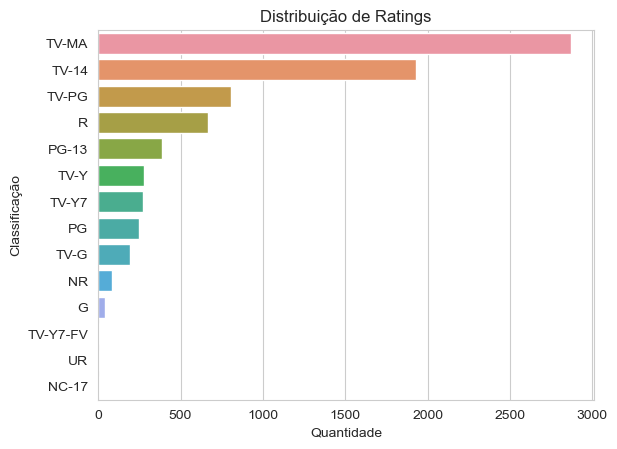

In [27]:
sns.countplot(data=df, y="rating", order=df["rating"].value_counts().index)

plt.title("Distribuição de Ratings")
plt.ylabel("Classificação")
plt.xlabel("Quantidade")
plt.savefig("C:\\Users\\vinir\\OneDrive\\Área de Trabalho\\devroot\\My-portifolio\\portifolio\\Limpeza de dados\\imgs\\Distribuicao_Ratings.png") 
plt.show()

### Insight:
Ratings como **TV-MA** e **TV-14** são predominantes, sugerindo foco em público adolescente e adulto.

## 📌 Conclusão

A análise revelou alguns padrões importantes:

- O catálogo é majoritariamente composto por filmes
- Estados Unidos lideram a produção
- Drama e comédia estão entre os gêneros mais frequentes
- Houve crescimento significativo na adição de conteúdos após 2016

Esses resultados refletem tanto a estratégia de expansão da plataforma quanto tendências da indústria audiovisual.

## 📌 DASHBOARD

Dashboard dos graficos apresentados.

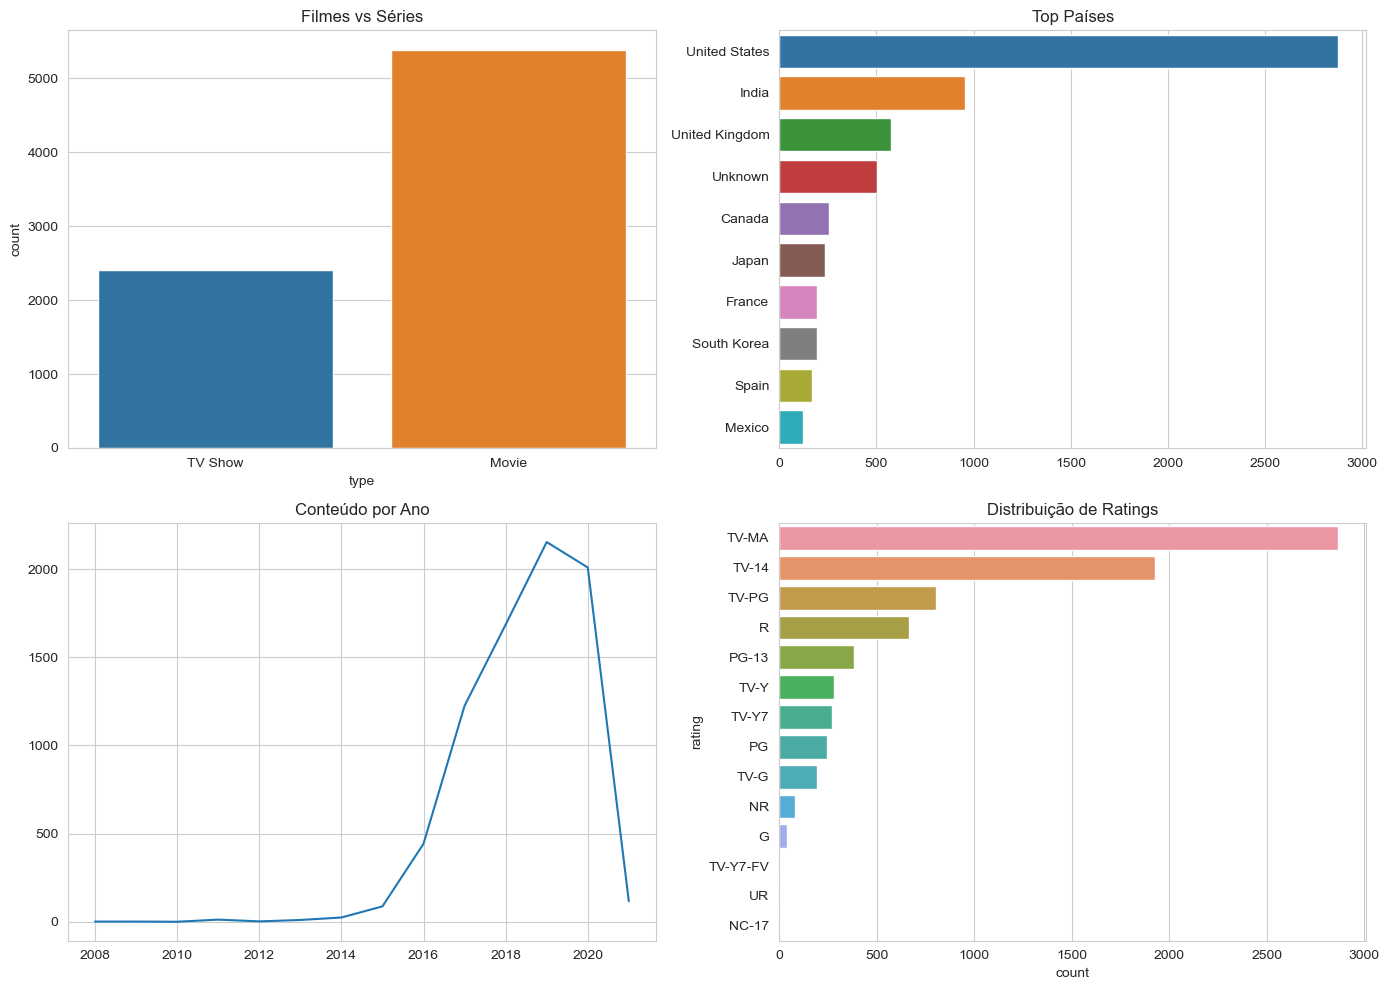

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Filmes vs séries
sns.countplot(data=df, x="type", ax=axes[0,0])
axes[0,0].set_title("Filmes vs Séries")

# Países
top_countries = df["country_main"].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0,1])
axes[0,1].set_title("Top Países")

# Conteúdo por ano
content_per_year = df["year_added"].value_counts().sort_index()
axes[1,0].plot(content_per_year)
axes[1,0].set_title("Conteúdo por Ano")

# Ratings
sns.countplot(data=df, y="rating", order=df["rating"].value_counts().index, ax=axes[1,1])
axes[1,1].set_title("Distribuição de Ratings")
    
plt.savefig("C:\\Users\\vinir\\OneDrive\\Área de Trabalho\\devroot\\My-portifolio\\portifolio\\Limpeza de dados\\imgs\\dashboard.png")    
plt.tight_layout()
plt.show()